In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import albumentations as A

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from ultralytics import YOLO

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tqdm.auto import tqdm

from breast_dataset import BUSIUNetDataset

warnings.filterwarnings('ignore')

import multiprocessing
try:
    multiprocessing.set_start_method('spawn', force=True)
except RuntimeError:
    pass

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
def setup_device():
    """Configure device for MacBook Air M4 10-core GPU"""
    
    # Check for MPS (Metal Performance Shaders) - Apple's GPU acceleration
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✅ Using Apple MPS (Metal) GPU acceleration")
        
        # MPS specific settings for stability
        torch.mps.set_per_process_memory_fraction(0.8)  # Use 70% of GPU memory
        
        # MPS currently has some limitations with certain operations
        print("  Note: Some operations may fall back to CPU for compatibility")
        
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"✅ Using CUDA GPU: {torch.cuda.get_device_name(0)}")
        
    else:
        device = torch.device("cpu")
        print("ℹ️ Using CPU (no GPU acceleration found)")
        
    return device

def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        # MPS doesn't have a dedicated seed function, but we set torch seed
        pass
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Initialize
set_seed(42)
device = setup_device()

✅ Using Apple MPS (Metal) GPU acceleration
  Note: Some operations may fall back to CPU for compatibility


In [4]:
root = Path("../../dataset/cropped_tumor_images")

benign_img_dir = root / "benign/images"
benign_mask_dir = root / "benign/masks"

malignant_img_dir = root / "malignant/images"
malignant_mask_dir = root / "malignant/masks"


def build_class_pairs(img_dir, mask_dir, class_name):
    records = []

    img_files = sorted(img_dir.glob("*.png"))

    for img_path in img_files:
        stem = img_path.stem   # e.g., "benign (1)"

        # mask filename
        mask_name = f"{stem}_mask.png"
        mask_path = mask_dir / mask_name


        # check existence
        if not mask_path.exists():
            continue

        records.append({
            "image_path": str(img_path),
            "mask_path": str(mask_path),
            "class_name": class_name
        })

    return records

In [5]:
records = []

records += build_class_pairs(
    benign_img_dir,
    benign_mask_dir,
    class_name="benign"
)

records += build_class_pairs(
    malignant_img_dir,
    malignant_mask_dir,
    class_name="malignant"
)

unet_df = pd.DataFrame(records)

print("Total samples:", len(unet_df))
unet_df.head()


Total samples: 647


,image_path,mask_path,class_name
0,../../dataset/cropped_tumor_images/benign/imag...,../../dataset/cropped_tumor_images/benign/mask...,benign
1,../../dataset/cropped_tumor_images/benign/imag...,../../dataset/cropped_tumor_images/benign/mask...,benign
2,../../dataset/cropped_tumor_images/benign/imag...,../../dataset/cropped_tumor_images/benign/mask...,benign
3,../../dataset/cropped_tumor_images/benign/imag...,../../dataset/cropped_tumor_images/benign/mask...,benign
4,../../dataset/cropped_tumor_images/benign/imag...,../../dataset/cropped_tumor_images/benign/mask...,benign


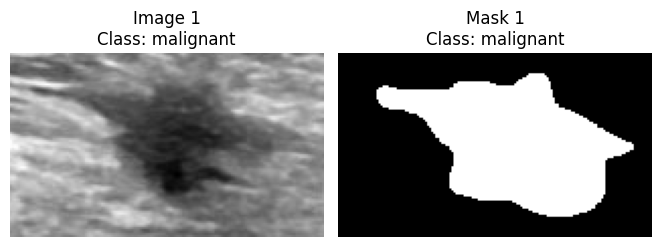

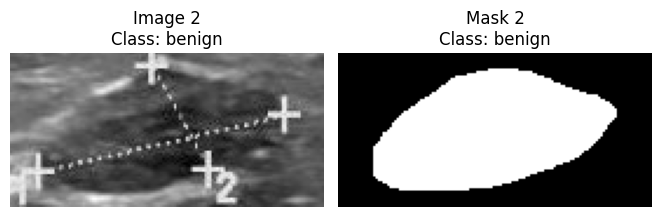

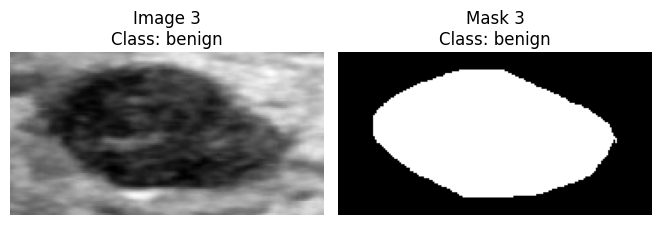

In [7]:
# Simple version - display images in a list
num_samples = 3

sample_rows = unet_df.sample(num_samples)

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    
    plt.figure(figsize=(10, 8))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Image {i+1}\nClass: {row['class_name']}")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {i+1}\nClass: {row['class_name']}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [8]:
unet_df_train, unet_df_temp = train_test_split(
    unet_df,
    test_size=0.30,
    random_state=42,
    stratify=unet_df["class_name"]
)

unet_df_val, unet_df_test = train_test_split(
    unet_df_temp,
    test_size=0.50,
    random_state=42,
    stratify=unet_df_temp["class_name"]
)


unet_df_train = unet_df_train.reset_index(drop=True)
unet_df_val   = unet_df_val.reset_index(drop=True)
unet_df_test  = unet_df_test.reset_index(drop=True)


In [9]:
print("Train:", len(unet_df_train))
print("Val  :", len(unet_df_val))
print("Test :", len(unet_df_test))


print("Train class counts:")
print(unet_df_train["class_name"].value_counts())

print("\nVal class counts:")
print(unet_df_val["class_name"].value_counts())

print("\nTest class counts:")
print(unet_df_test["class_name"].value_counts())

Train: 452
Val  : 97
Test : 98
Train class counts:
class_name
benign       305
malignant    147
Name: count, dtype: int64

Val class counts:
class_name
benign       66
malignant    31
Name: count, dtype: int64

Test class counts:
class_name
benign       66
malignant    32
Name: count, dtype: int64


In [10]:
train_aug = A.Compose(
    [
        A.Resize(256, 256),
        A.Rotate(limit=10, p=0.5),
        A.Affine(
            translate_percent=0.05,
            scale=(0.95, 1.05),
            rotate=0,
            p=0.5
        ),
        A.GaussianBlur(blur_limit=(3, 3), p=0.2),
    ]
)

val_aug = A.Compose(
    [
        A.Resize(256, 256),
    ]
)

In [11]:
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'
train_ds = BUSIUNetDataset(unet_df_train, augment=train_aug)
val_ds   = BUSIUNetDataset(unet_df_val, augment=val_aug)
test_ds  = BUSIUNetDataset(unet_df_test, augment=val_aug)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=8)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=8)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=8)

x, y = next(iter(train_loader))
print("Input shape:", x.shape)
print("Mask shape:", y.shape)

Input shape: torch.Size([8, 1, 256, 256])
Mask shape: torch.Size([8, 1, 256, 256])


In [12]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.outc = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.outc(d1)

In [13]:
def dice_score(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    inter = (pred * target).sum()
    return (2 * inter + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return (inter + smooth) / (union + smooth)

def pixel_accuracy(pred, target):
    pred = pred.view(-1)
    target = target.view(-1)
    return (pred == target).float().mean()

def batch_metrics(logits, target, thr=0.5):
    probs = torch.sigmoid(logits)
    pred = (probs > thr).float()

    dice = dice_score(pred, target).item()
    iou = iou_score(pred, target).item()
    acc = pixel_accuracy(pred, target).item()
    return dice, iou, acc

In [15]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        dice = 1 - dice_score((probs > 0.5).float(), targets)
        return bce + dice

In [16]:

model = UNet(in_channels=1, out_channels=1).to(device)
criterion = DiceBCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 50
best_val_dice = -1
history = []

save_path = "../second_project/best_unet.pth"

# Create a single progress bar for epochs
epoch_bar = tqdm(range(num_epochs), desc="Training Progress", position=0)

for epoch in epoch_bar:

    # ------------------ TRAIN ------------------
    model.train()
    train_loss = train_dice = train_iou = train_acc = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False, position=1)

    for x, y in train_bar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        d, i, a = batch_metrics(logits.detach(), y)

        train_loss += loss.item()
        train_dice += d
        train_iou += i
        train_acc += a

        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "dice": f"{d:.4f}",
            "iou": f"{i:.4f}",
            "acc": f"{a:.4f}"
        })

    # ------------------ VALIDATION ------------------
    model.eval()
    val_loss = val_dice = val_iou = val_acc = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False, position=1)

    with torch.no_grad():
        for x, y in val_bar:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            d, i, a = batch_metrics(logits, y)

            val_loss += loss.item()
            val_dice += d
            val_iou += i
            val_acc += a

            val_bar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "dice": f"{d:.4f}",
                "iou": f"{i:.4f}",
                "acc": f"{a:.4f}"
            })

    # ------------------ AVERAGE METRICS ------------------
    train_loss /= len(train_loader)
    train_dice /= len(train_loader)
    train_iou /= len(train_loader)
    train_acc /= len(train_loader)

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)
    val_acc /= len(val_loader)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_dice": train_dice,
        "train_iou": train_iou,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_dice": val_dice,
        "val_iou": val_iou,
        "val_acc": val_acc
    })

    # ------------------ SAVE BEST ------------------
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), save_path)

    # Update the main progress bar with current metrics
    epoch_bar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "val_loss": f"{val_loss:.4f}",
        "val_dice": f"{val_dice:.4f}"
    })

print("\nTraining completed!")

Training Progress: 100%|██████████| 50/50 [1:29:29<00:00, 107.39s/it, train_loss=0.2140, val_loss=0.3219, val_dice=0.9019]


Training completed!


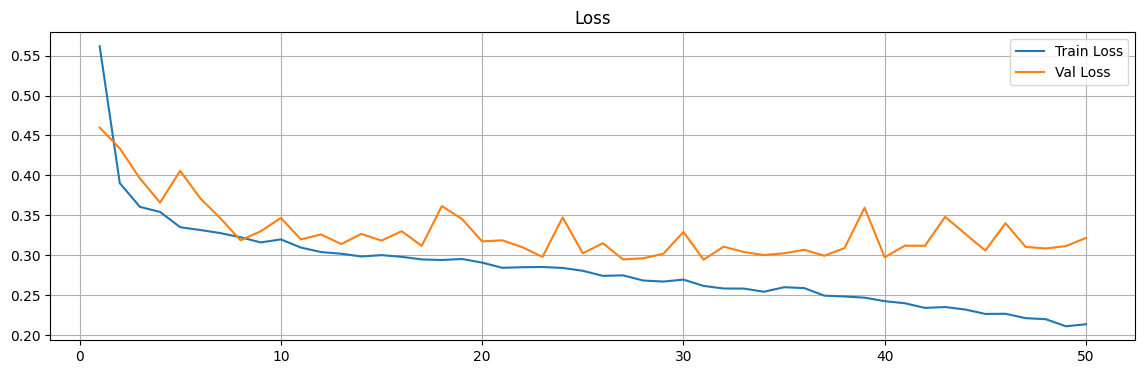

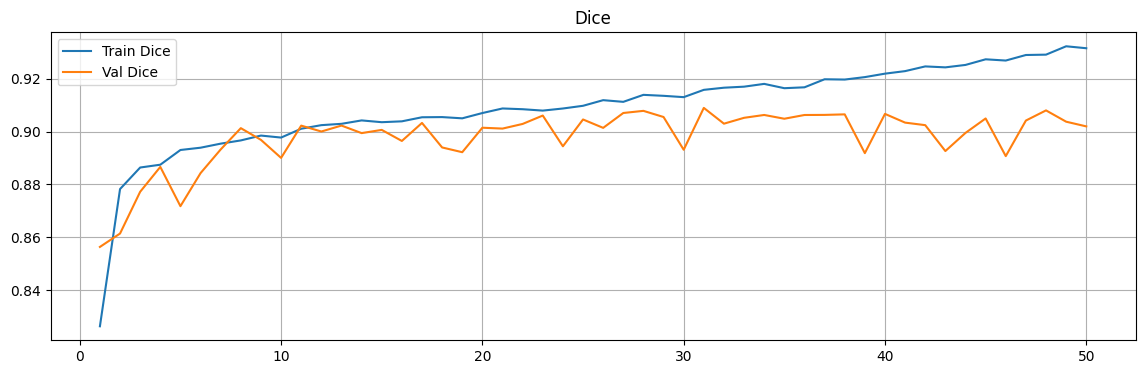

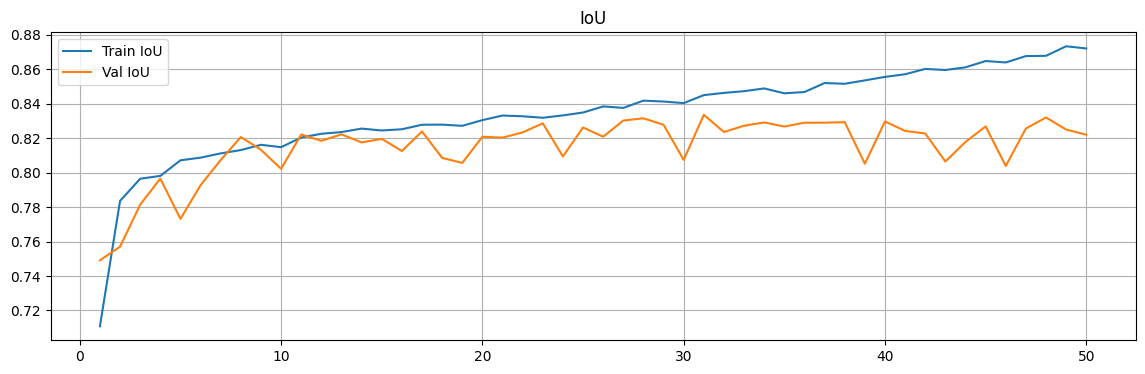

In [17]:
hist_df = pd.DataFrame(history)

plt.figure(figsize=(14, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(hist_df["epoch"], hist_df["train_dice"], label="Train Dice")
plt.plot(hist_df["epoch"], hist_df["val_dice"], label="Val Dice")
plt.legend()
plt.title("Dice")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(hist_df["epoch"], hist_df["train_iou"], label="Train IoU")
plt.plot(hist_df["epoch"], hist_df["val_iou"], label="Val IoU")
plt.legend()
plt.title("IoU")
plt.grid(True)
plt.show()

In [18]:
model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

test_loss = 0
test_dice = 0
test_iou = 0
test_acc = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing U-Net"):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        d = dice_score(preds, y).item()
        i = iou_score(preds, y).item()
        a = pixel_accuracy(preds, y).item()

        test_loss += loss.item()
        test_dice += d
        test_iou += i
        test_acc += a

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

test_loss /= len(test_loader)
test_dice /= len(test_loader)
test_iou /= len(test_loader)
test_acc /= len(test_loader)

print("U-Net Test Loss:", test_loss)
print("U-Net Test Dice:", test_dice)
print("U-Net Test IoU:", test_iou)
print("U-Net Test Pixel Accuracy:", test_acc)

Testing U-Net: 100%|██████████| 13/13 [00:45<00:00,  3.48s/it]


U-Net Test Loss: 0.304932095683538
U-Net Test Dice: 0.9053701116488531
U-Net Test IoU: 0.8276605422680194
U-Net Test Pixel Accuracy: 0.9131616445688101


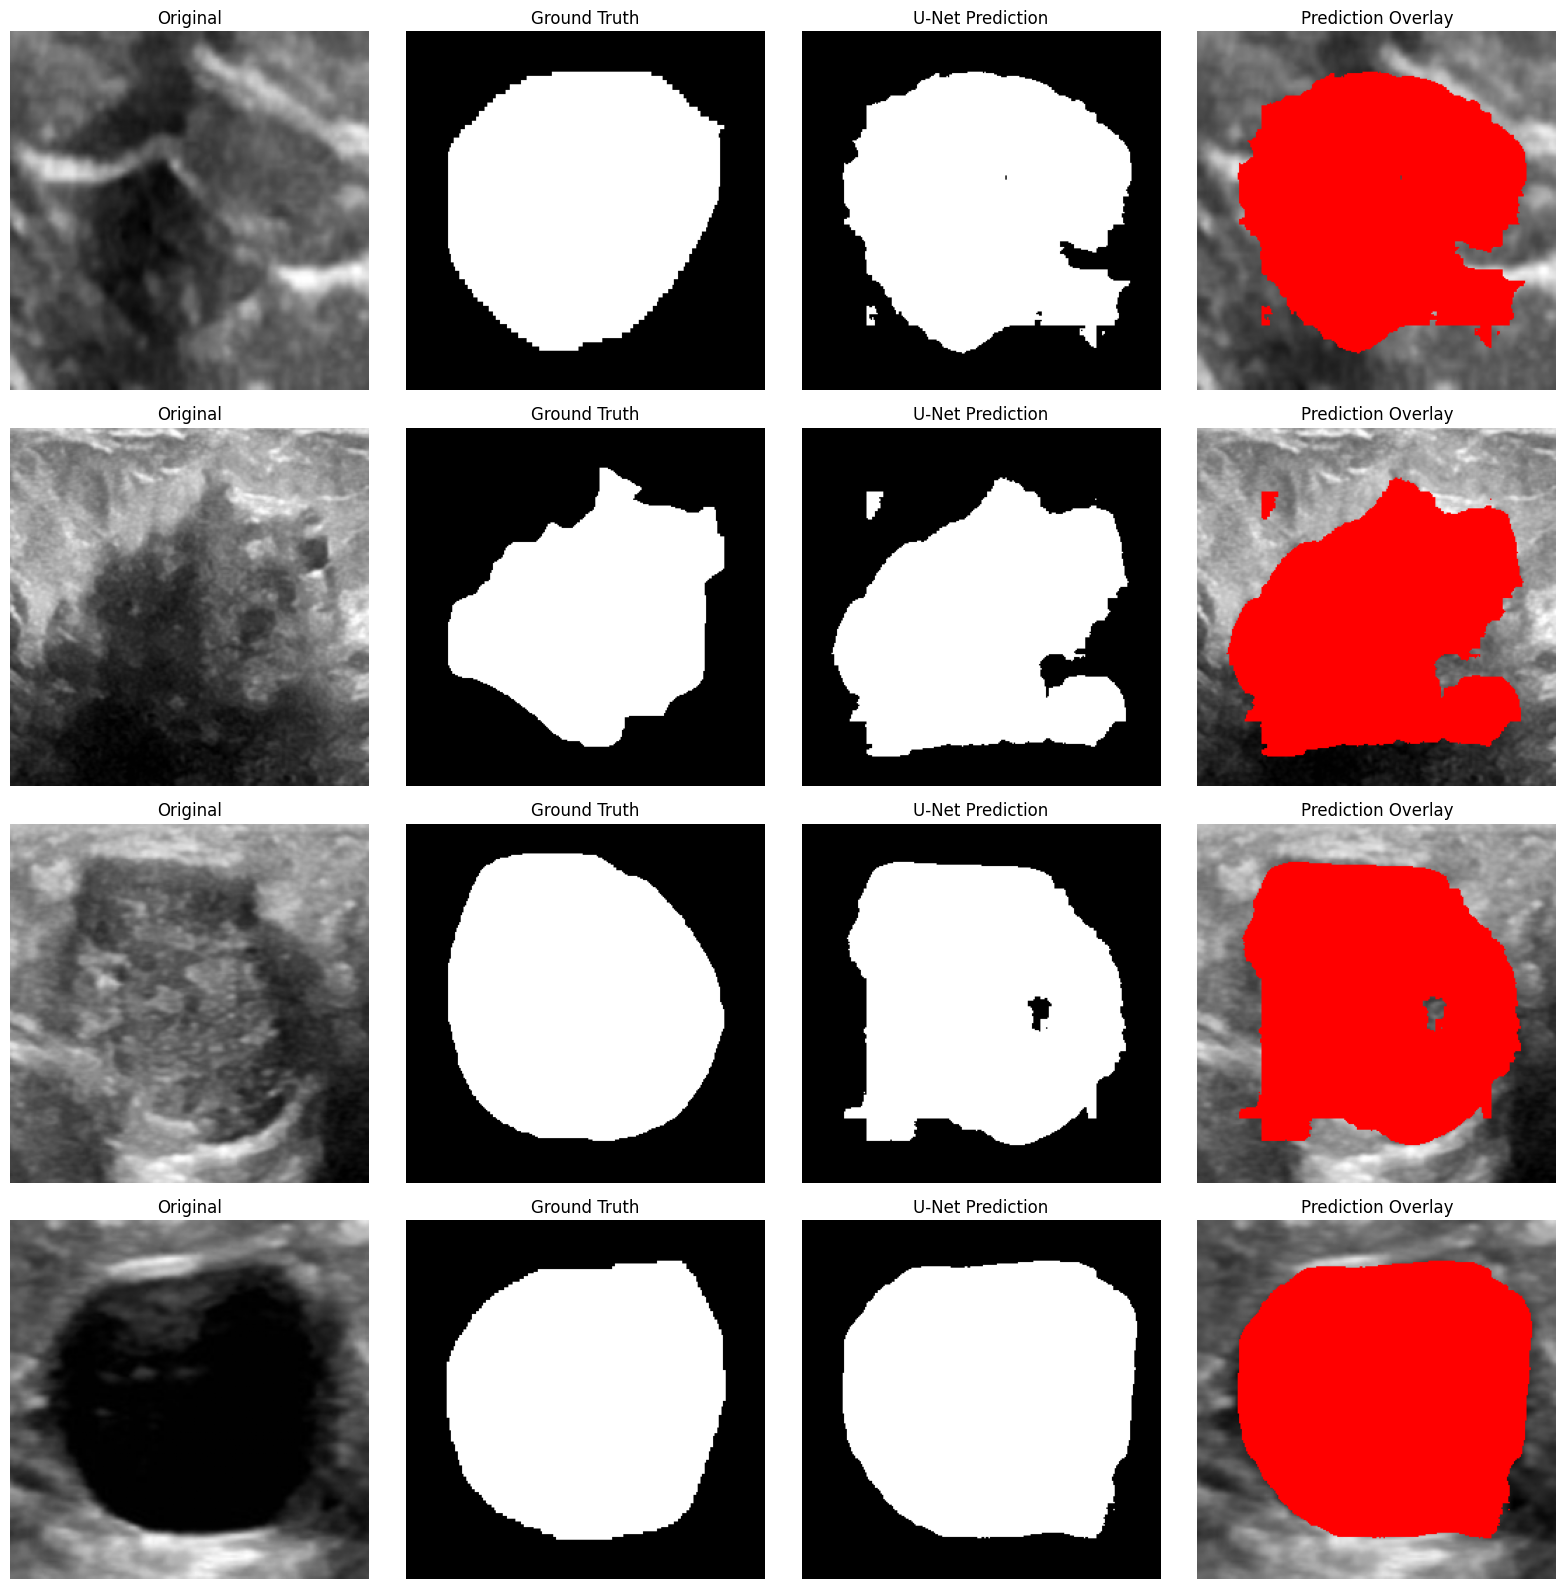

In [28]:
def visualize_unet_results(dataset, model, n=4):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    fig, axes = plt.subplots(len(idxs), 4, figsize=(16, 4 * len(idxs)))
    if len(idxs) == 1:
        axes = np.expand_dims(axes, 0)

    with torch.no_grad():
        for r, idx in enumerate(idxs):
            x, y = dataset[idx]
            inp = x.unsqueeze(0).to(device)
            logits = model(inp)
            pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()

            orig = x[0].numpy()
            gt = y.squeeze().numpy()

            overlay = np.dstack([orig, orig, orig])
            overlay[pred > 0] = [1, 0, 0]

            axes[r, 0].imshow(orig, cmap="gray")
            axes[r, 0].set_title("Original")
            axes[r, 0].axis("off")

            axes[r, 1].imshow(gt, cmap="gray")
            axes[r, 1].set_title("Ground Truth")
            axes[r, 1].axis("off")

            axes[r, 2].imshow(pred, cmap="gray")
            axes[r, 2].set_title("U-Net Prediction")
            axes[r, 2].axis("off")

            axes[r, 3].imshow(overlay)
            axes[r, 3].set_title("Prediction Overlay")
            axes[r, 3].axis("off")

    plt.tight_layout()
    plt.show()

visualize_unet_results(test_ds, model, n=4)